<a href="https://colab.research.google.com/github/Deepikadandolu/Tsetlin_Machines_Projects/blob/main/SMS_Classification(DL).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import nltk, re, collections, pickle, os # nltk - Natural Language Toolkit
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout, Bidirectional
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

plt.rcParams['figure.figsize'] = (15, 5)
plt.style.use('ggplot')
seed = 42

import warnings
warnings.filterwarnings(action = "ignore")
warnings.simplefilter(action = 'ignore', category = Warning)

In [2]:
pd.options.display.float_format = '{:.3f}'.format

In [3]:
def plot_history(history):
    loss_list = [s for s in history.history.keys() if 'loss' in s and 'val' not in s]
    val_loss_list = [s for s in history.history.keys() if 'loss' in s and 'val' in s]
    acc_list = [s for s in history.history.keys() if 'accuracy' in s and 'val' not in s]
    val_acc_list = [s for s in history.history.keys() if 'accuracy' in s and 'val' in s]

    plt.figure(figsize = (12, 5), dpi = 100)
    COLOR = 'gray'

    plt.rc('legend', fontsize = 14)   # legend fontsize
    plt.rc('figure', titlesize = 12)  # fontsize of the figure title

    if len(loss_list) == 0:
        print('Loss is missing in history')
        return

    ## As loss always exists
    epochs = range(1, len(history.history[loss_list[0]]) + 1)

    ## Loss
    plt.subplot(1, 2, 1)
    plt.subplots_adjust(wspace = 2, hspace = 2)
    plt.rcParams['text.color'] = 'black'
    plt.rcParams['axes.titlecolor'] = 'black'
    plt.rcParams['axes.labelcolor'] = COLOR
    plt.rcParams['xtick.color'] = COLOR
    plt.rcParams['ytick.color'] = COLOR
    for l in loss_list:
        plt.plot(epochs, history.history[l], 'b-o',
                 label = 'Train (' + str(str(format(history.history[l][-1],'.4f'))+')'))
    for l in val_loss_list:
        plt.plot(epochs, history.history[l], 'g',
                 label = 'Valid (' + str(str(format(history.history[l][-1],'.4f'))+')'))

    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.legend(facecolor = 'gray', loc = 'best')
    plt.grid(True)
    plt.tight_layout()

    ## Accuracy
    plt.subplot(1, 2, 2)
    plt.subplots_adjust(wspace = 2, hspace = 2)
    plt.rcParams['text.color'] = 'black'
    plt.rcParams['axes.titlecolor'] = 'black'
    plt.rcParams['axes.labelcolor'] = COLOR
    plt.rcParams['xtick.color'] = COLOR
    plt.rcParams['ytick.color'] = COLOR
    for l in acc_list:
        plt.plot(epochs, history.history[l], 'b-o',
                 label = 'Train (' + str(format(history.history[l][-1],'.4f'))+')')
    for l in val_acc_list:
        plt.plot(epochs, history.history[l], 'g',
                 label = 'Valid (' + str(format(history.history[l][-1],'.4f'))+')')

    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.legend(facecolor = 'gray', loc = 'best')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_conf_matr(conf_matr, classes,
                          normalize = False,
                          title = 'Confusion matrix',
                          cmap = plt.cm.winter):
  """
  Citation
  ---------
  http://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html

  """
  import itertools

  accuracy = np.trace(conf_matr) / np.sum(conf_matr).astype('float')
  sns.set(font_scale = 1.4)

  plt.figure(figsize = (12, 8))
  plt.imshow(conf_matr, interpolation = 'nearest', cmap = cmap)
  title = '\n' + title + '\n'
  plt.title(title)
  plt.colorbar()

  if classes is not None:
      tick_marks = np.arange(len(classes))
      plt.xticks(tick_marks, classes, rotation = 45)
      plt.yticks(tick_marks, classes)

  if normalize:
      conf_matr = conf_matr.astype('float') / conf_matr.sum(axis = 1)[:, np.newaxis]


  thresh = conf_matr.max() / 1.5 if normalize else conf_matr.max() / 2
  for i, j in itertools.product(range(conf_matr.shape[0]), range(conf_matr.shape[1])):
      if normalize:
          plt.text(j, i, "{:0.2f}%".format(conf_matr[i, j] * 100),
                    horizontalalignment = "center",
                    fontweight = 'bold',
                    color = "white" if conf_matr[i, j] > thresh else "black")
      else:
          plt.text(j, i, "{:,}".format(conf_matr[i, j]),
                    horizontalalignment = "center",
                    fontweight = 'bold',
                    color = "white" if conf_matr[i, j] > thresh else "black")
  plt.tight_layout()
  plt.ylabel('True label')
  plt.xlabel('Predicted label\n\nAccuracy = {:0.2f}%; Error = {:0.2f}%'.format(accuracy * 100, (1 - accuracy) * 100))
  plt.show()


def plot_words(set, number):
  words_counter = collections.Counter([word for sentence in set for word in sentence.split()]) # finding words along with count
  most_counted = words_counter.most_common(number)
  most_count = pd.DataFrame(most_counted, columns = ["Words", "Amount"]).sort_values(by = "Amount") # sorted data frame
  most_count.plot.barh(x = "Words",
                       y = "Amount",
                       color = "blue",
                       figsize = (10, 15))
  for i, v in enumerate(most_count["Amount"]):
    plt.text(v, i,
             " " + str(v),
             color = 'black',
             va = 'center',
             fontweight = 'bold')

def word_cloud(tag):
  df_words_nl = ' '.join(list(df_spam[df_spam['feature'] == tag]['message']))
  df_wc_nl = WordCloud(width = 600, height = 512).generate(df_words_nl)
  plt.figure(figsize = (13, 9), facecolor = 'k')
  plt.imshow(df_wc_nl)
  plt.axis('off')
  plt.tight_layout(pad = 1)
  plt.show()

In [5]:
import kagglehub

path = kagglehub.dataset_download(
    "hamnawaseem112222222/sms-spam-collection-5572-labeled-sms-messages"
)

print(path)

100%|██████████| 208k/208k [00:00<00:00, 59.7MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/hamnawaseem112222222/sms-spam-collection-5572-labeled-sms-messages/versions/1


In [6]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/hamnawaseem112222222/sms-spam-collection-5572-labeled-sms-messages/versions/1/sms_spam_collection (1).csv


In [8]:
import os

csv_file = os.path.join(
    path,
    "sms_spam_collection (1).csv"
)

df_spam = pd.read_csv(csv_file)

df_spam.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
print(df_spam.columns)

Index(['label', 'message'], dtype='object')


In [22]:
df_spam = pd.read_csv(csv_file)
df_spam.columns = ['feature', 'message']

df_spam.drop_duplicates(
    inplace=True,
    ignore_index=True
)

df_spam['feature'] = df_spam['feature'].map({
    'ham': 0,
    'spam': 1
})

df_spam.head()

,feature,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df_spam['feature'].value_counts()

,count
feature,
0,4516
1,653


In [14]:
df_spam.shape, df_spam.columns

((5169, 2), Index(['feature', 'message'], dtype='object'))

In [15]:
df_spam.describe().T

,count,mean,std,min,25%,50%,75%,max
feature,5169.000,0.126,0.332,0.000,0.000,0.000,0.000,1.000


In [16]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

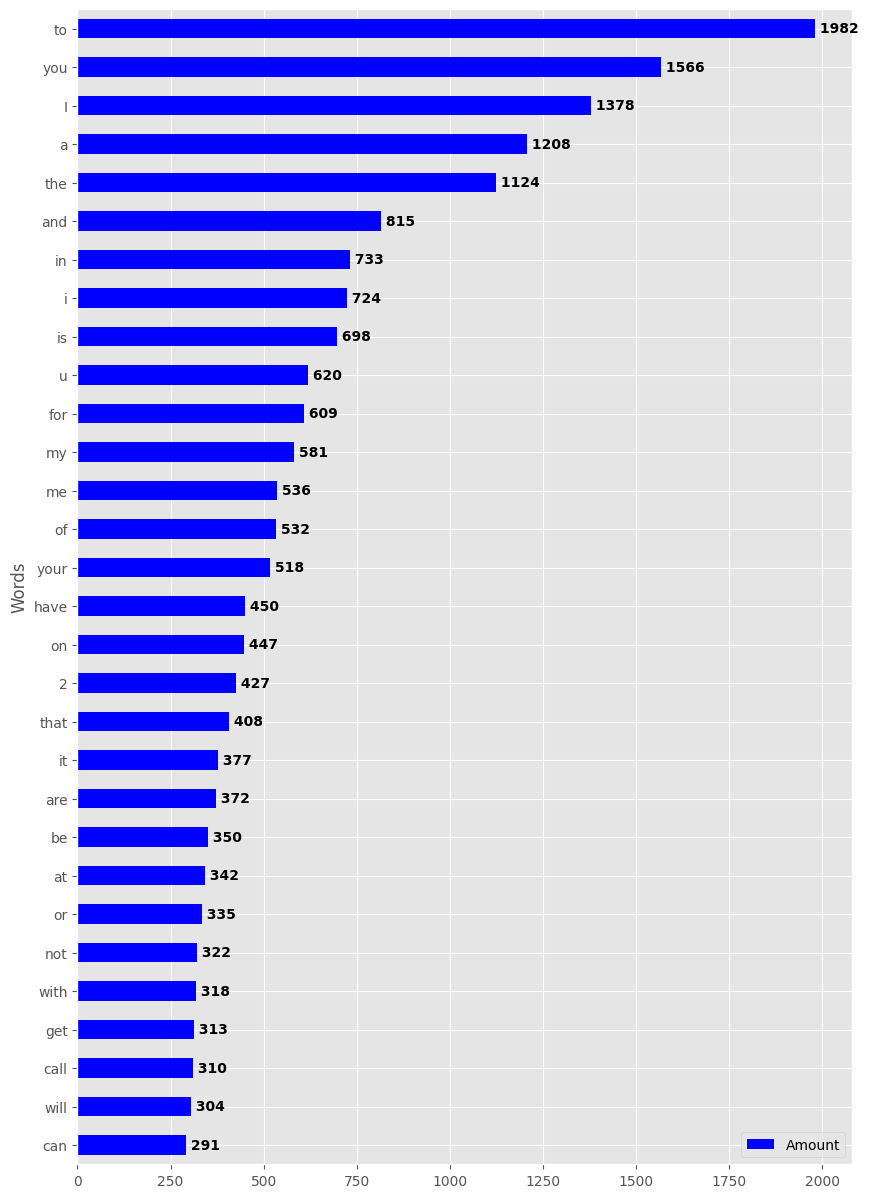

In [17]:
plot_words(df_spam['message'], number = 30)

In [18]:
size_vocabulary = 1000
embedding_dimension = 64
trunc_type = 'post'
padding_type = 'post'
threshold = 0.5
oov_token = "<OOV>"
test_size, valid_size = 0.05, 0.2
num_epochs = 20
drop_level = 0.3

In [19]:
print("\t\tStage I. Preliminary actions. Preparing of needed sets\n")
full_df_l = []
lemmatizer = WordNetLemmatizer()
for i in range(df_spam.shape[0]):
    mess_1 = df_spam.iloc[i, 1]
    mess_1 = re.sub('\b[\w\-.]+?@\w+?\.\w{2,4}\b', 'emailaddr', mess_1)
    mess_1 = re.sub('(http[s]?\S+)|(\w+\.[A-Za-z]{2,4}\S*)', 'httpaddr', mess_1)
    mess_1 = re.sub('£|\$', 'moneysymb', mess_1)
    mess_1 = re.sub('\b(\+\d{1,2}\s)?\d?[\-(.]?\d{3}\)?[\s.-]?\d{3}[\s.-]?\d{4}\b', 'phonenumbr', mess_1)
    mess_1 = re.sub('\d+(\.\d+)?', 'numbr', mess_1)
    mess_1 = re.sub('[^\w\d\s]', ' ', mess_1)
    mess_1 = re.sub('[^A-Za-z]', ' ', mess_1).lower()
    token_messages = word_tokenize(mess_1)
    mess = []
    for word in token_messages:
        if word not in set(stopwords.words('english')):
            mess.append(lemmatizer.lemmatize(word))
    txt_mess = " ".join(mess)
    full_df_l.append(txt_mess)

		Stage I. Preliminary actions. Preparing of needed sets



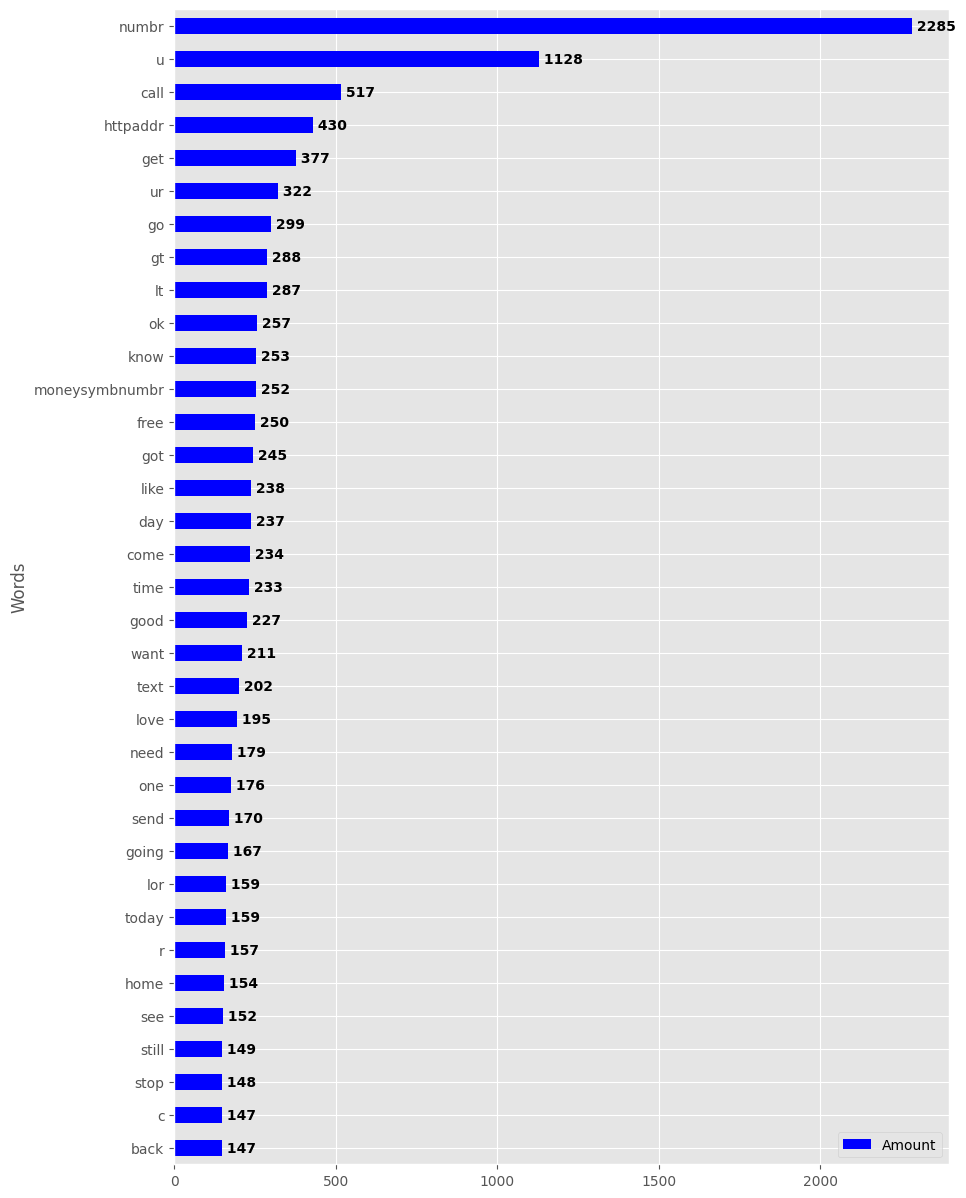

In [20]:
plot_words(full_df_l, number = 35)

In [23]:
import joblib
import os

SAVE_DIR = "/content/drive/MyDrive/SMS_Benchmark_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

add_df = CountVectorizer(max_features = size_vocabulary)
X = add_df.fit_transform(full_df_l).toarray()
y = df_spam.iloc[:, 0]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = (test_size + valid_size), random_state = seed)
print('Number of rows in test set: ' + str(X_test.shape))
print('Number of rows in training set: ' + str(X_train.shape))
joblib.dump(
    add_df,
    f"{SAVE_DIR}/count_vectorizer_dl.pkl"
)

Number of rows in test set: (1293, 1000)
Number of rows in training set: (3876, 1000)


['/content/drive/MyDrive/SMS_Benchmark_Models/count_vectorizer_dl.pkl']

		Stage IIa. Guassian Naive Bayes

The first two predicted labels: 0 1 

			Classification report:

               precision    recall  f1-score   support

           0       0.99      0.79      0.88      1124
           1       0.40      0.95      0.56       169

    accuracy                           0.81      1293
   macro avg       0.70      0.87      0.72      1293
weighted avg       0.91      0.81      0.84      1293
 



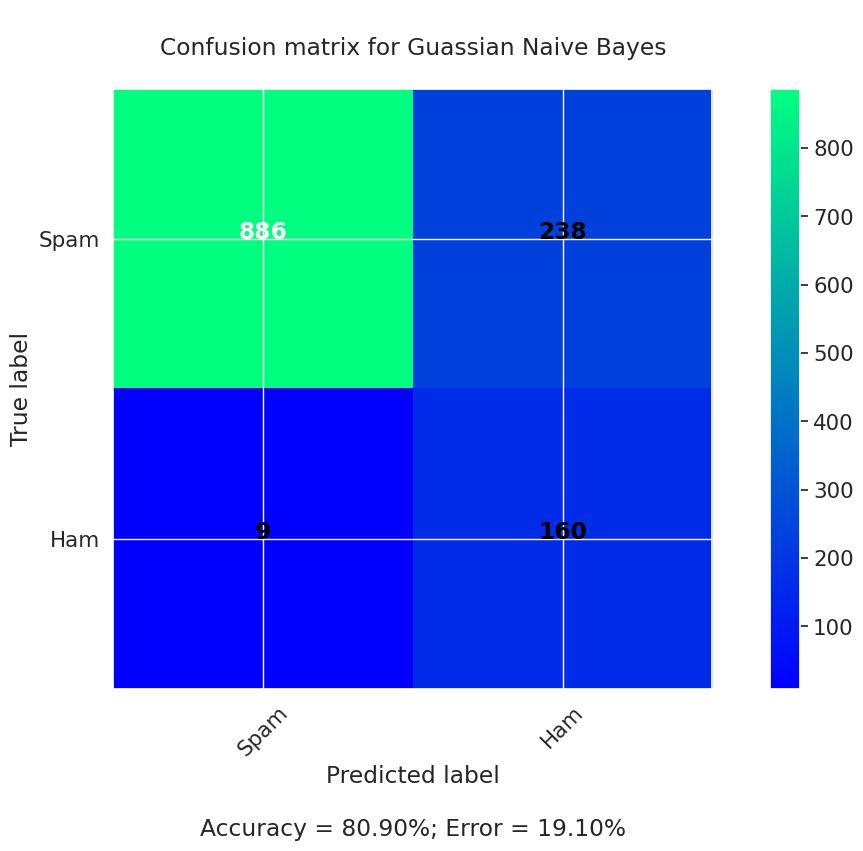

In [24]:
print("\t\tStage IIa. Guassian Naive Bayes\n")
class_NBC = GaussianNB().fit(X_train, y_train) # Guassian Naive Bayes
y_pred_NBC = class_NBC.predict(X_test)
print('The first two predicted labels:', y_pred_NBC[0],y_pred_NBC[1], '\n')
conf_m_NBC = confusion_matrix(y_test, y_pred_NBC)
class_rep_NBC = classification_report(y_test, y_pred_NBC)
print('\t\t\tClassification report:\n\n', class_rep_NBC, '\n')
plot_conf_matr(conf_m_NBC, classes = ['Spam','Ham'], normalize = False, title = 'Confusion matrix for Guassian Naive Bayes')

In [28]:
import os

print(os.listdir('/content'))

['.config', 'drive', 'sample_data']


In [30]:
!ls /content/drive

MyDrive


In [31]:
import os
import joblib

SAVE_DIR = "/content/drive/MyDrive/SMS_Benchmark_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(
    class_NBC,
    f"{SAVE_DIR}/gaussian_nb.pkl"
)

print("GaussianNB saved successfully.")


GaussianNB saved successfully.


In [32]:
!ls -lh /content/drive/MyDrive/SMS_Benchmark_Models

total 64K
-rw-r--r-- 1 root root 27K Jun  3 10:36 count_vectorizer_dl.pkl
-rw-r--r-- 1 root root 33K Jun  3 10:41 gaussian_nb.pkl


import joblib

gaussian_nb = joblib.load(
    "/content/drive/MyDrive/SMS_Benchmark_Models/gaussian_nb.pkl"
)

		Stage IIb. Multinomial Naive Bayes

The first two predicted labels: 0 1 

			Classification report:

               precision    recall  f1-score   support

           0       0.99      0.98      0.98      1124
           1       0.87      0.93      0.90       169

    accuracy                           0.97      1293
   macro avg       0.93      0.96      0.94      1293
weighted avg       0.97      0.97      0.97      1293
 



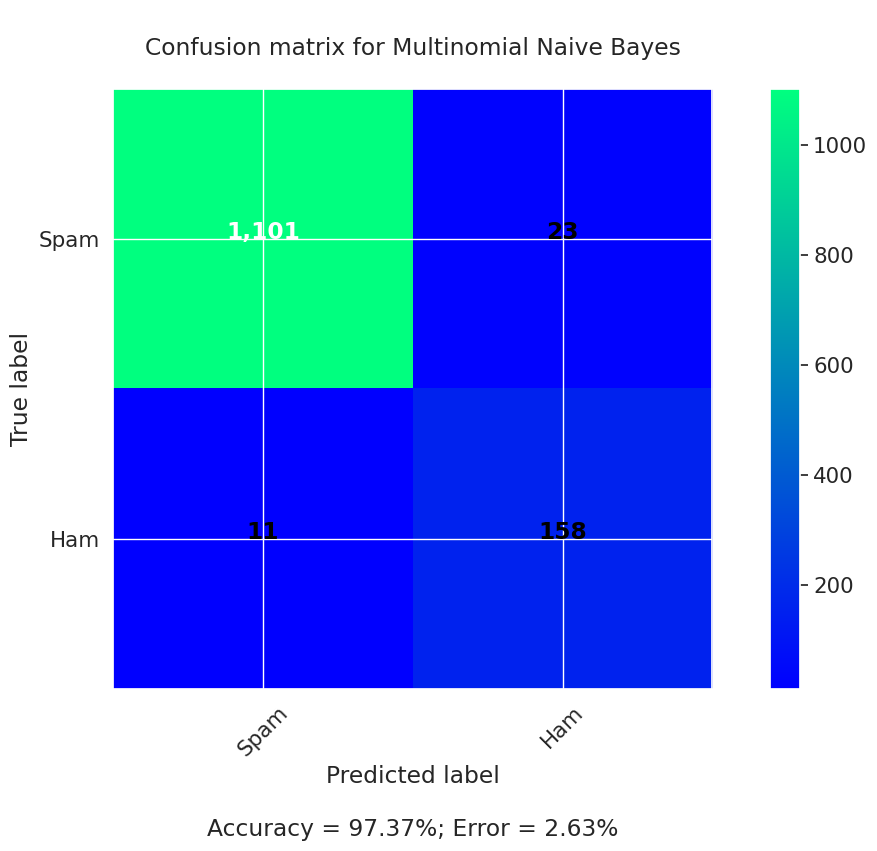

In [33]:
print("\t\tStage IIb. Multinomial Naive Bayes\n")
class_MNB = MultinomialNB().fit(X_train, y_train) # Multinomial Naive Bayes
y_pred_MNB = class_MNB.predict(X_test)
print('The first two predicted labels:', y_pred_MNB[0],y_pred_MNB[1], '\n')
conf_m_MNB = confusion_matrix(y_test, y_pred_MNB)
class_rep_MNB = classification_report(y_test, y_pred_MNB)
print('\t\t\tClassification report:\n\n', class_rep_MNB, '\n')
plot_conf_matr(conf_m_MNB, classes = ['Spam','Ham'], normalize = False, title = 'Confusion matrix for Multinomial Naive Bayes')

In [35]:
# Save Multinomial Naive Bayes Model to Google Drive

import os
import joblib

SAVE_DIR = "/content/drive/MyDrive/SMS_Benchmark_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(
    class_MNB,
    f"{SAVE_DIR}/multinomial_nb.pkl"
)

print("MultinomialNB saved successfully.")

MultinomialNB saved successfully.


import joblib

multinomial_nb = joblib.load(
    "/content/drive/MyDrive/SMS_Benchmark_Models/multinomial_nb.pkl"
)

print("MultinomialNB loaded successfully.")

In [36]:
!ls -lh /content/drive/MyDrive/SMS_Benchmark_Models

total 100K
-rw-r--r-- 1 root root 27K Jun  3 10:36 count_vectorizer_dl.pkl
-rw-r--r-- 1 root root 33K Jun  3 10:41 gaussian_nb.pkl
-rw-r--r-- 1 root root 33K Jun  3 10:42 multinomial_nb.pkl


		Stage IV. Logistic Regression

The first two predicted labels: 0 1 

			Classification report:

               precision    recall  f1-score   support

           0       0.98      0.99      0.99      1124
           1       0.96      0.89      0.92       169

    accuracy                           0.98      1293
   macro avg       0.97      0.94      0.95      1293
weighted avg       0.98      0.98      0.98      1293
 



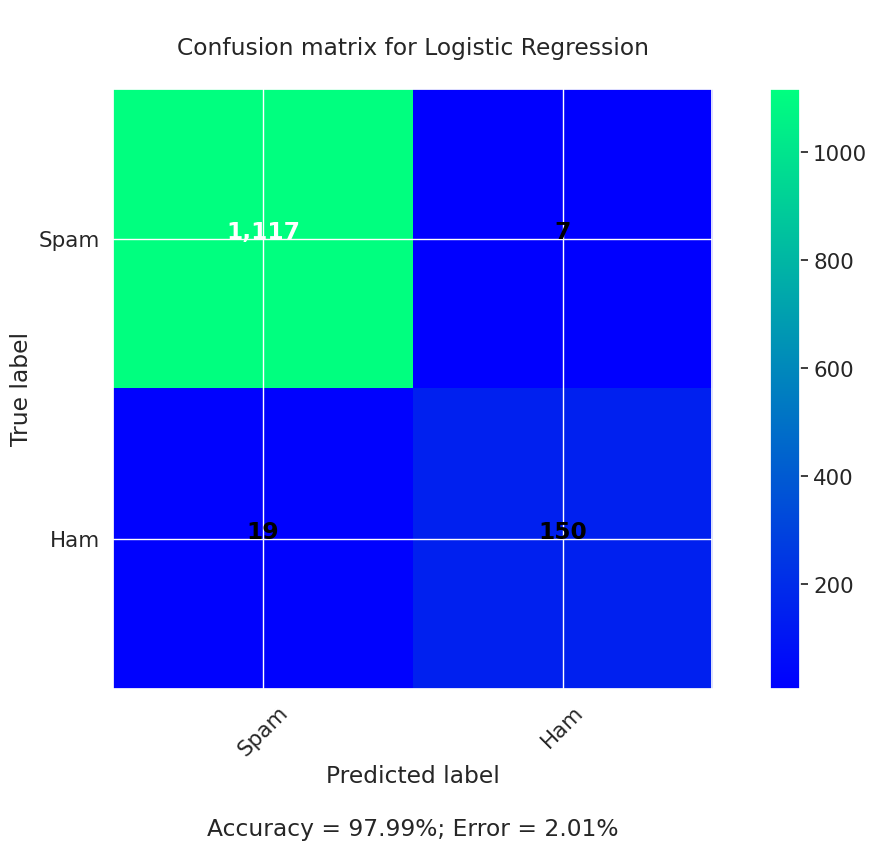

In [37]:
print("\t\tStage IV. Logistic Regression\n")
class_LR = LogisticRegression(random_state = seed, solver = 'liblinear').fit(X_train, y_train)
y_pred_LR = class_LR.predict(X_test)
print('The first two predicted labels:', y_pred_LR[0], y_pred_LR[1], '\n')
conf_m_LR = confusion_matrix(y_test, y_pred_LR)
class_rep_LR = classification_report(y_test, y_pred_LR)
print('\t\t\tClassification report:\n\n', class_rep_LR, '\n')
plot_conf_matr(conf_m_LR, classes = ['Spam','Ham'], normalize = False, title = 'Confusion matrix for Logistic Regression')

In [39]:
# Save Logistic Regression Model to Google Drive

import os
import joblib

SAVE_DIR = "/content/drive/MyDrive/SMS_Benchmark_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

joblib.dump(
    class_LR,
    f"{SAVE_DIR}/logistic_regression.pkl"
)

print("Logistic Regression model saved successfully.")

Logistic Regression model saved successfully.


import joblib

logistic_regression = joblib.load(
    "/content/drive/MyDrive/SMS_Benchmark_Models/logistic_regression.pkl"
)

print("Logistic Regression model loaded successfully.")

In [40]:
!ls -lh /content/drive/MyDrive/SMS_Benchmark_Models

total 112K
-rw-r--r-- 1 root root  27K Jun  3 10:36 count_vectorizer_dl.pkl
-rw-r--r-- 1 root root  33K Jun  3 10:41 gaussian_nb.pkl
-rw-r--r-- 1 root root 8.7K Jun  3 10:42 logistic_regression.pkl
-rw-r--r-- 1 root root  33K Jun  3 10:42 multinomial_nb.pkl


## **BI LSTM**

In [83]:
#Cell 1: Create Sentences and Labels
sentences = df_spam["message"].values
labels = df_spam["feature"].values

In [84]:
#Cell 2: Stratified Train/Validation/Test Split
from sklearn.model_selection import train_test_split

train_sentences, temp_sentences, train_labels, temp_labels = train_test_split(
    sentences,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

valid_sentences, test_sentences, valid_labels, test_labels = train_test_split(
    temp_sentences,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

In [85]:
#Cell 3: Verify Split
import numpy as np

print("Train:", np.bincount(train_labels))
print("Valid:", np.bincount(valid_labels))
print("Test :", np.bincount(test_labels))

Train: [3161  457]
Valid: [677  98]
Test : [678  98]


In [86]:
#Cell 4: Tokenization
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(
    num_words=size_vocabulary,
    oov_token=oov_token
)

tokenizer.fit_on_texts(train_sentences)

word_index = tokenizer.word_index
size_voc = len(word_index) + 1

In [87]:
#Cell 5: Convert Text to Sequences
train_sequences = tokenizer.texts_to_sequences(train_sentences)
valid_sequences = tokenizer.texts_to_sequences(valid_sentences)
test_sequences = tokenizer.texts_to_sequences(test_sentences)

max_len = max(len(seq) for seq in train_sequences)

print("Vocabulary Size:", size_voc)
print("Max Length:", max_len)

Vocabulary Size: 7334
Max Length: 189


In [88]:
#Cell 6: Padding
from tensorflow.keras.preprocessing.sequence import pad_sequences

train_set = pad_sequences(
    train_sequences,
    maxlen=max_len,
    padding=padding_type,
    truncating=trunc_type
)

valid_set = pad_sequences(
    valid_sequences,
    maxlen=max_len,
    padding=padding_type,
    truncating=trunc_type
)

test_set = pad_sequences(
    test_sequences,
    maxlen=max_len,
    padding=padding_type,
    truncating=trunc_type
)

In [90]:
#Cell 7: Save Tokenizer
import pickle

SAVE_DIR = "/content/drive/MyDrive/SMS_Benchmark_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

with open(
    f"{SAVE_DIR}/tokenizer_dl.pkl",
    "wb"
) as f:
    pickle.dump(tokenizer, f)

print("Tokenizer saved successfully.")

Tokenizer saved successfully.


In [91]:
#Cell 8: Build BiLSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM
from tensorflow.keras.layers import Dense, Dropout

model = Sequential([
    Embedding(
        input_dim=size_voc,
        output_dim=embedding_dimension,
        input_shape=(max_len,)
    ),

    Bidirectional(
        LSTM(100)
    ),

    Dropout(drop_level),

    Dense(20, activation="relu"),

    Dropout(drop_level),

    Dense(1, activation="sigmoid")
])

In [92]:
#Cell 9: Compile
from tensorflow.keras.optimizers import Adam

optim = Adam(learning_rate=0.0003)

model.compile(
    loss="binary_crossentropy",
    optimizer=optim,
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 189, 64)        │       469,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 200)            │       132,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 20)             │         4,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,417 (2.31 MB)

 Trainable params: 605,417 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

In [94]:
#Cell 10: Train
history = model.fit(
    train_set,
    train_labels,
    epochs=10,
    validation_data=(valid_set, valid_labels),
    verbose=1
)

Epoch 1/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 31s 267ms/step - accuracy: 0.9624 - loss: 0.1420 - val_accuracy: 0.9729 - val_loss: 0.0992
Epoch 2/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 38s 244ms/step - accuracy: 0.9812 - loss: 0.0644 - val_accuracy: 0.9677 - val_loss: 0.1258
Epoch 3/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 40s 238ms/step - accuracy: 0.9848 - loss: 0.0515 - val_accuracy: 0.9755 - val_loss: 0.0835
Epoch 4/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - accuracy: 0.9876 - loss: 0.0471 - val_accuracy: 0.9742 - val_loss: 0.0809
Epoch 5/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - accuracy: 0.9914 - loss: 0.0342 - val_accuracy: 0.9768 - val_loss: 0.0738
Epoch 6/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 41s 236ms/step - accuracy: 0.9925 - loss: 0.0247 - val_accuracy: 0.9768 - val_loss: 0.0778
Epoch 7/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 27s 235ms/step - accuracy: 0.9956 - loss: 0.0204 - val_accuracy: 0.9768 - val_loss: 0.0808
Epoch 8/10
114/114 ━━━━━━━━━━━━━━━━━━━━ 27s 235ms/step - accuracy: 0.9950 - loss: 0

In [95]:
#Cell 11: Evaluate
model_score = model.evaluate(
    test_set,
    test_labels,
    verbose=1
)

print(
    f"Test Accuracy: {model_score[1]*100:.2f}%"
)

25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9832 - loss: 0.0834
Test Accuracy: 98.32%


In [96]:
#Cell 12: Save Model
import os

SAVE_DIR = "/content/drive/MyDrive/SMS_Benchmark_Models"
os.makedirs(SAVE_DIR, exist_ok=True)

model.save(
    f"{SAVE_DIR}/bilstm_dl.keras"
)

print("BiLSTM saved successfully.")

BiLSTM saved successfully.


In [97]:
#Cell 13: Predictions
y_pred_bLSTM = model.predict(test_set)

y_prediction = (
    y_pred_bLSTM > threshold
).astype(int).flatten()

25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step


In [98]:
#Cell 14: Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print(
    "Accuracy:",
    accuracy_score(
        test_labels,
        y_prediction
    )
)

print(
    confusion_matrix(
        test_labels,
        y_prediction
    )
)

print(
    classification_report(
        test_labels,
        y_prediction
    )
)

Accuracy: 0.9832474226804123
[[673   5]
 [  8  90]]
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       678
           1       0.95      0.92      0.93        98

    accuracy                           0.98       776
   macro avg       0.97      0.96      0.96       776
weighted avg       0.98      0.98      0.98       776



In [99]:
!ls -lh /content/drive/MyDrive/SMS_Benchmark_Models

total 7.4M
-rw-r--r-- 1 root root 7.0M Jun  3 11:36 bilstm_dl.keras
-rw-r--r-- 1 root root  27K Jun  3 10:36 count_vectorizer_dl.pkl
-rw-r--r-- 1 root root  33K Jun  3 10:41 gaussian_nb.pkl
-rw-r--r-- 1 root root 8.7K Jun  3 10:42 logistic_regression.pkl
-rw-r--r-- 1 root root  33K Jun  3 10:42 multinomial_nb.pkl
-rw-r--r-- 1 root root 278K Jun  3 11:28 tokenizer_dl.pkl


In [100]:
# You can change this message (as any short sentence) yourself
message_example = ["Darling, please give me a cup of tea"]

message_example_tp = pad_sequences(tokenizer.texts_to_sequences(message_example),
                                   maxlen = max_len,
                                   padding = padding_type,
                                   truncating = trunc_type)

pred = float(model.predict(message_example_tp))
if (pred > threshold):
    print ("This message is a real text")
else:
    print("This message is a spam message")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
This message is a spam message


Stage VI. Results visualization



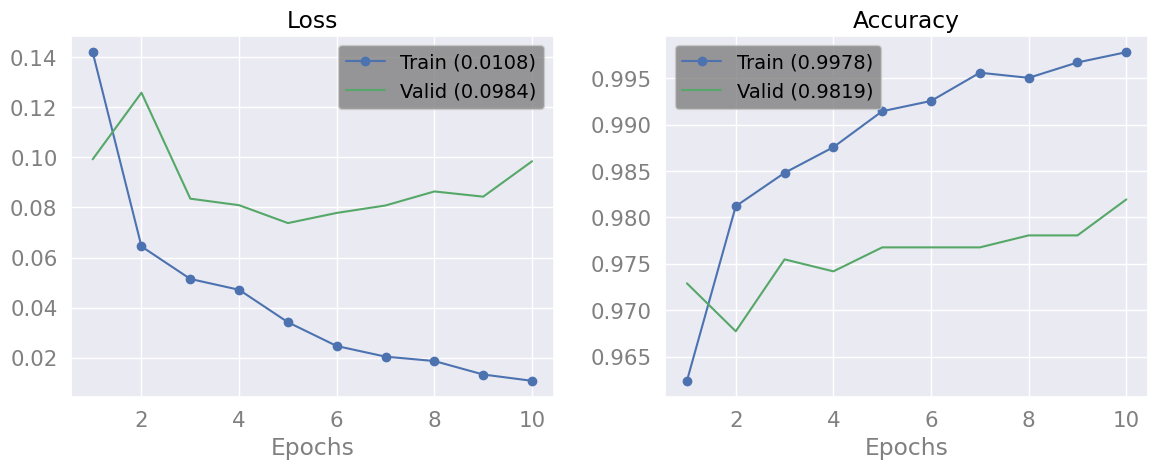

In [101]:
print("Stage VI. Results visualization\n")
plot_history(history)